# ДЗ 2 — Fine-tuning DETR на COCO-subset 
**Что делает:** загружает маленький detection-датасет (CPPE-5, COCO-формат), дообучает `facebook/detr-resnet-50`, логирует loss в TensorBoard, снимает trace профайлера, сохраняет чекпойнты, строит графики потерь / mAP и проводит error analysis.


## 1. Проверка GPU

In [1]:
!nvidia-smi -L || echo 'GPU не найден — Runtime > Change runtime type > GPU'
import torch
print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())

zsh:1: command not found: nvidia-smi
GPU не найден — Runtime > Change runtime type > GPU
torch 2.7.0 | cuda available: False


In [ ]:
# import os

# REPO_URL = ""  # напр. https://github.com/<user>/<repo>.git
# WORK = "/content/hw3"

# if REPO_URL:
#     !git clone $REPO_URL $WORK
# else:
#     os.makedirs(WORK, exist_ok=True)
#     print("REPO_URL пуст: загрузите src/ в", WORK, "через панель Files,")
#     print("либо впишите REPO_URL и перезапустите ячейку.")

# os.chdir(WORK)
# print("CWD:", os.getcwd())
# !ls -la

In [6]:
import sys
sys.path.append('..')
sys.path.append('.')

## 3. Установка зависимостей

В Colab уже есть `torch`, `torchvision`, `matplotlib`, `pillow`, `scipy` — доустанавливаем остальное.

In [2]:
!pip -q install "transformers>=4.40" "datasets>=2.18" timm torchmetrics pycocotools tensorboard
print('done')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
done


## 4. Обучение

/Users/a.fida/Desktop/code/hse/cv_hse_hw3/notebooks


In [15]:
!CURL_CA_BUNDLE="" REQUESTS_CA_BUNDLE="" python3.11 ../src/train.py --train-size 300 --val-size 100 --epochs 12 --batch-size 4 --image-short 600 --image-long 1000
# !CURL_CA_BUNDLE="" REQUESTS_CA_BUNDLE="" python3.11 ../src/train.py --epochs 30 --batch-size 4 --image-short 800 --image-long 1333

[setup] device = mps
preprocessor_config.json: 100%|█████████████████| 290/290 [00:00<00:00, 428kB/s]
README.md: 11.2kB [00:00, 10.6MB/s]
data/train-00000-of-00001.parquet: 100%|█████| 237M/237M [00:30<00:00, 7.80MB/s]
data/test-00000-of-00001.parquet: 100%|████| 4.14M/4.14M [00:01<00:00, 2.32MB/s]
Generating test split: 100%|███████████| 29/29 [00:00<00:00, 7045.58 examples/s]
[data] train=300 val=29 classes=['Coverall', 'Face_Shield', 'Gloves', 'Goggles', 'Mask']
config.json: 4.59kB [00:00, 13.1MB/s]
model.safetensors: 100%|█████████████████████| 167M/167M [00:15<00:00, 10.4MB/s]
model.safetensors: 100%|█████████████████████| 102M/102M [00:09<00:00, 10.7MB/s]
/opt/homebrew/lib/python3.11/site-packages/torch/nn/modules/module.py:2409: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the m

## 5. Таблица метрик (mAP / mAP50)

In [17]:
from IPython.display import Markdown, Image, display
display(Markdown(open('../outputs/metrics.md').read()))

| epoch | loss | loss_ce | loss_bbox | loss_giou | mAP | mAP50 | mAP75 |
|------:|-----:|--------:|----------:|----------:|----:|------:|------:|
| 1 | 3.203 | 1.641 | 0.124 | 0.472 | 0.0113 | 0.0272 | 0.0100 |
| 2 | 3.153 | 1.595 | 0.124 | 0.469 | 0.0113 | 0.0260 | 0.0098 |
| 3 | 3.014 | 1.549 | 0.115 | 0.444 | 0.0148 | 0.0357 | 0.0110 |
| 4 | 2.776 | 1.406 | 0.107 | 0.416 | 0.0257 | 0.0493 | 0.0220 |
| 5 | 2.492 | 1.153 | 0.105 | 0.409 | 0.0457 | 0.0778 | 0.0444 |
| 6 | 2.360 | 1.058 | 0.102 | 0.397 | 0.0631 | 0.1057 | 0.0635 |

**Лучшая эпоха:** 6 — mAP=0.0631, mAP50=0.1057

## 6. Графики потерь и mAP

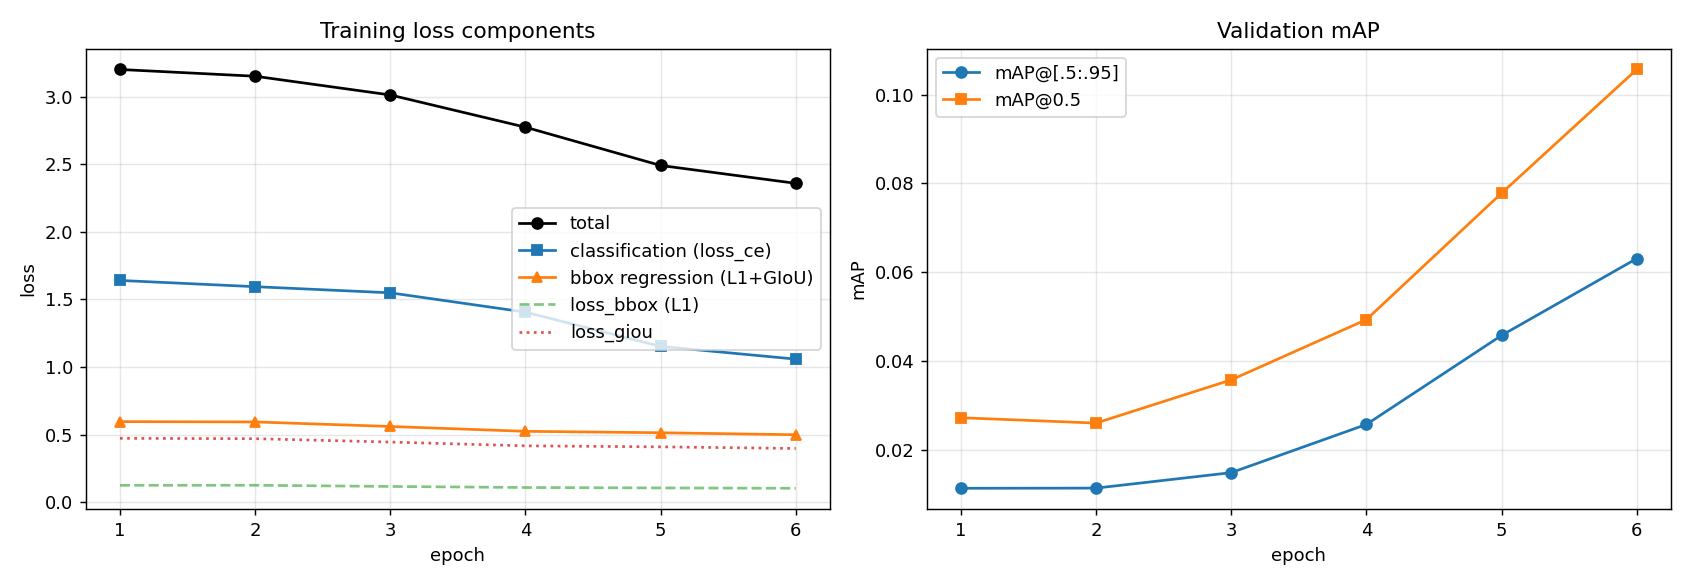

In [19]:
Image('../outputs/figures/loss_and_map.png')

## 7. Error analysis

`--threshold` подбирайте под уверенность модели: после короткого обучения score низкие (0.1–0.3), после полного прогона можно 0.5–0.7.

In [20]:
!python ../src/error_analysis.py --ckpt outputs/checkpoints/best.pt --val-size 100 --threshold 0.3 --n-viz 8

  File "../src/error_analysis.py", line 1
SyntaxError: Non-ASCII character '\xd0' in file ../src/error_analysis.py on line 1, but no encoding declared; see http://python.org/dev/peps/pep-0263/ for details


| Категория | Кол-во | % от предсказаний |
|-----------|-------:|------------------:|
| Верно (класс+локализация) | 55 | 5.7% |
| Ошибка локализации (0.1<=IoU<0.5) | 440 | 45.3% |
| Ошибка классификации (IoU>=0.5, класс неверный) | 105 | 10.8% |
| Дубликаты | 79 | 8.1% |
| Ложные срабатывания (фон, IoU<0.1) | 293 | 30.1% |
| Пропущенные объекты (FN) | 152 | — |

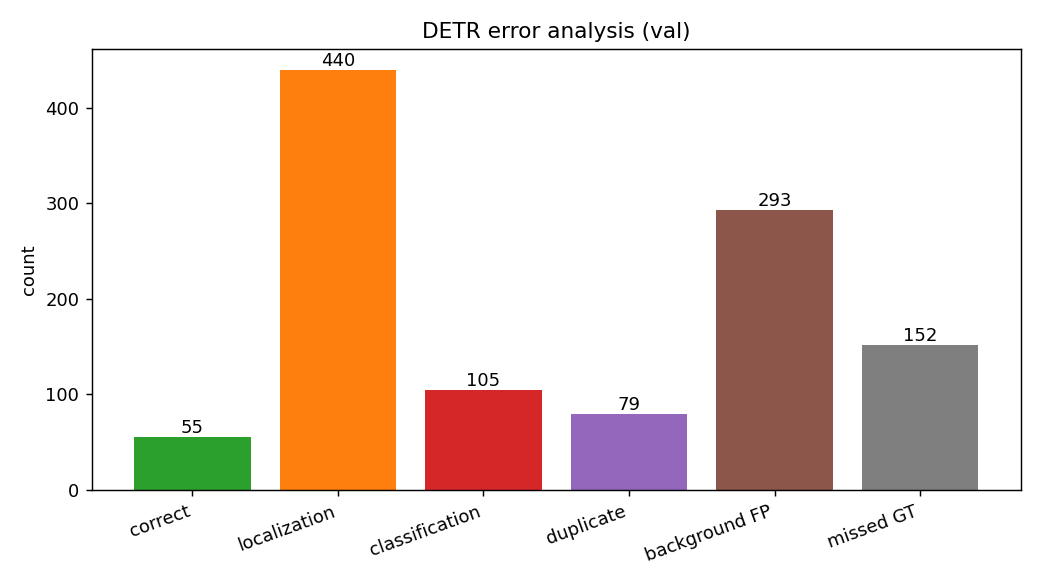

In [22]:
display(Markdown(open('../outputs/error_analysis.md').read()))
display(Image('../outputs/figures/error_analysis.png'))

### Предсказанные боксы (красные) vs ground truth (зелёные пунктирные)

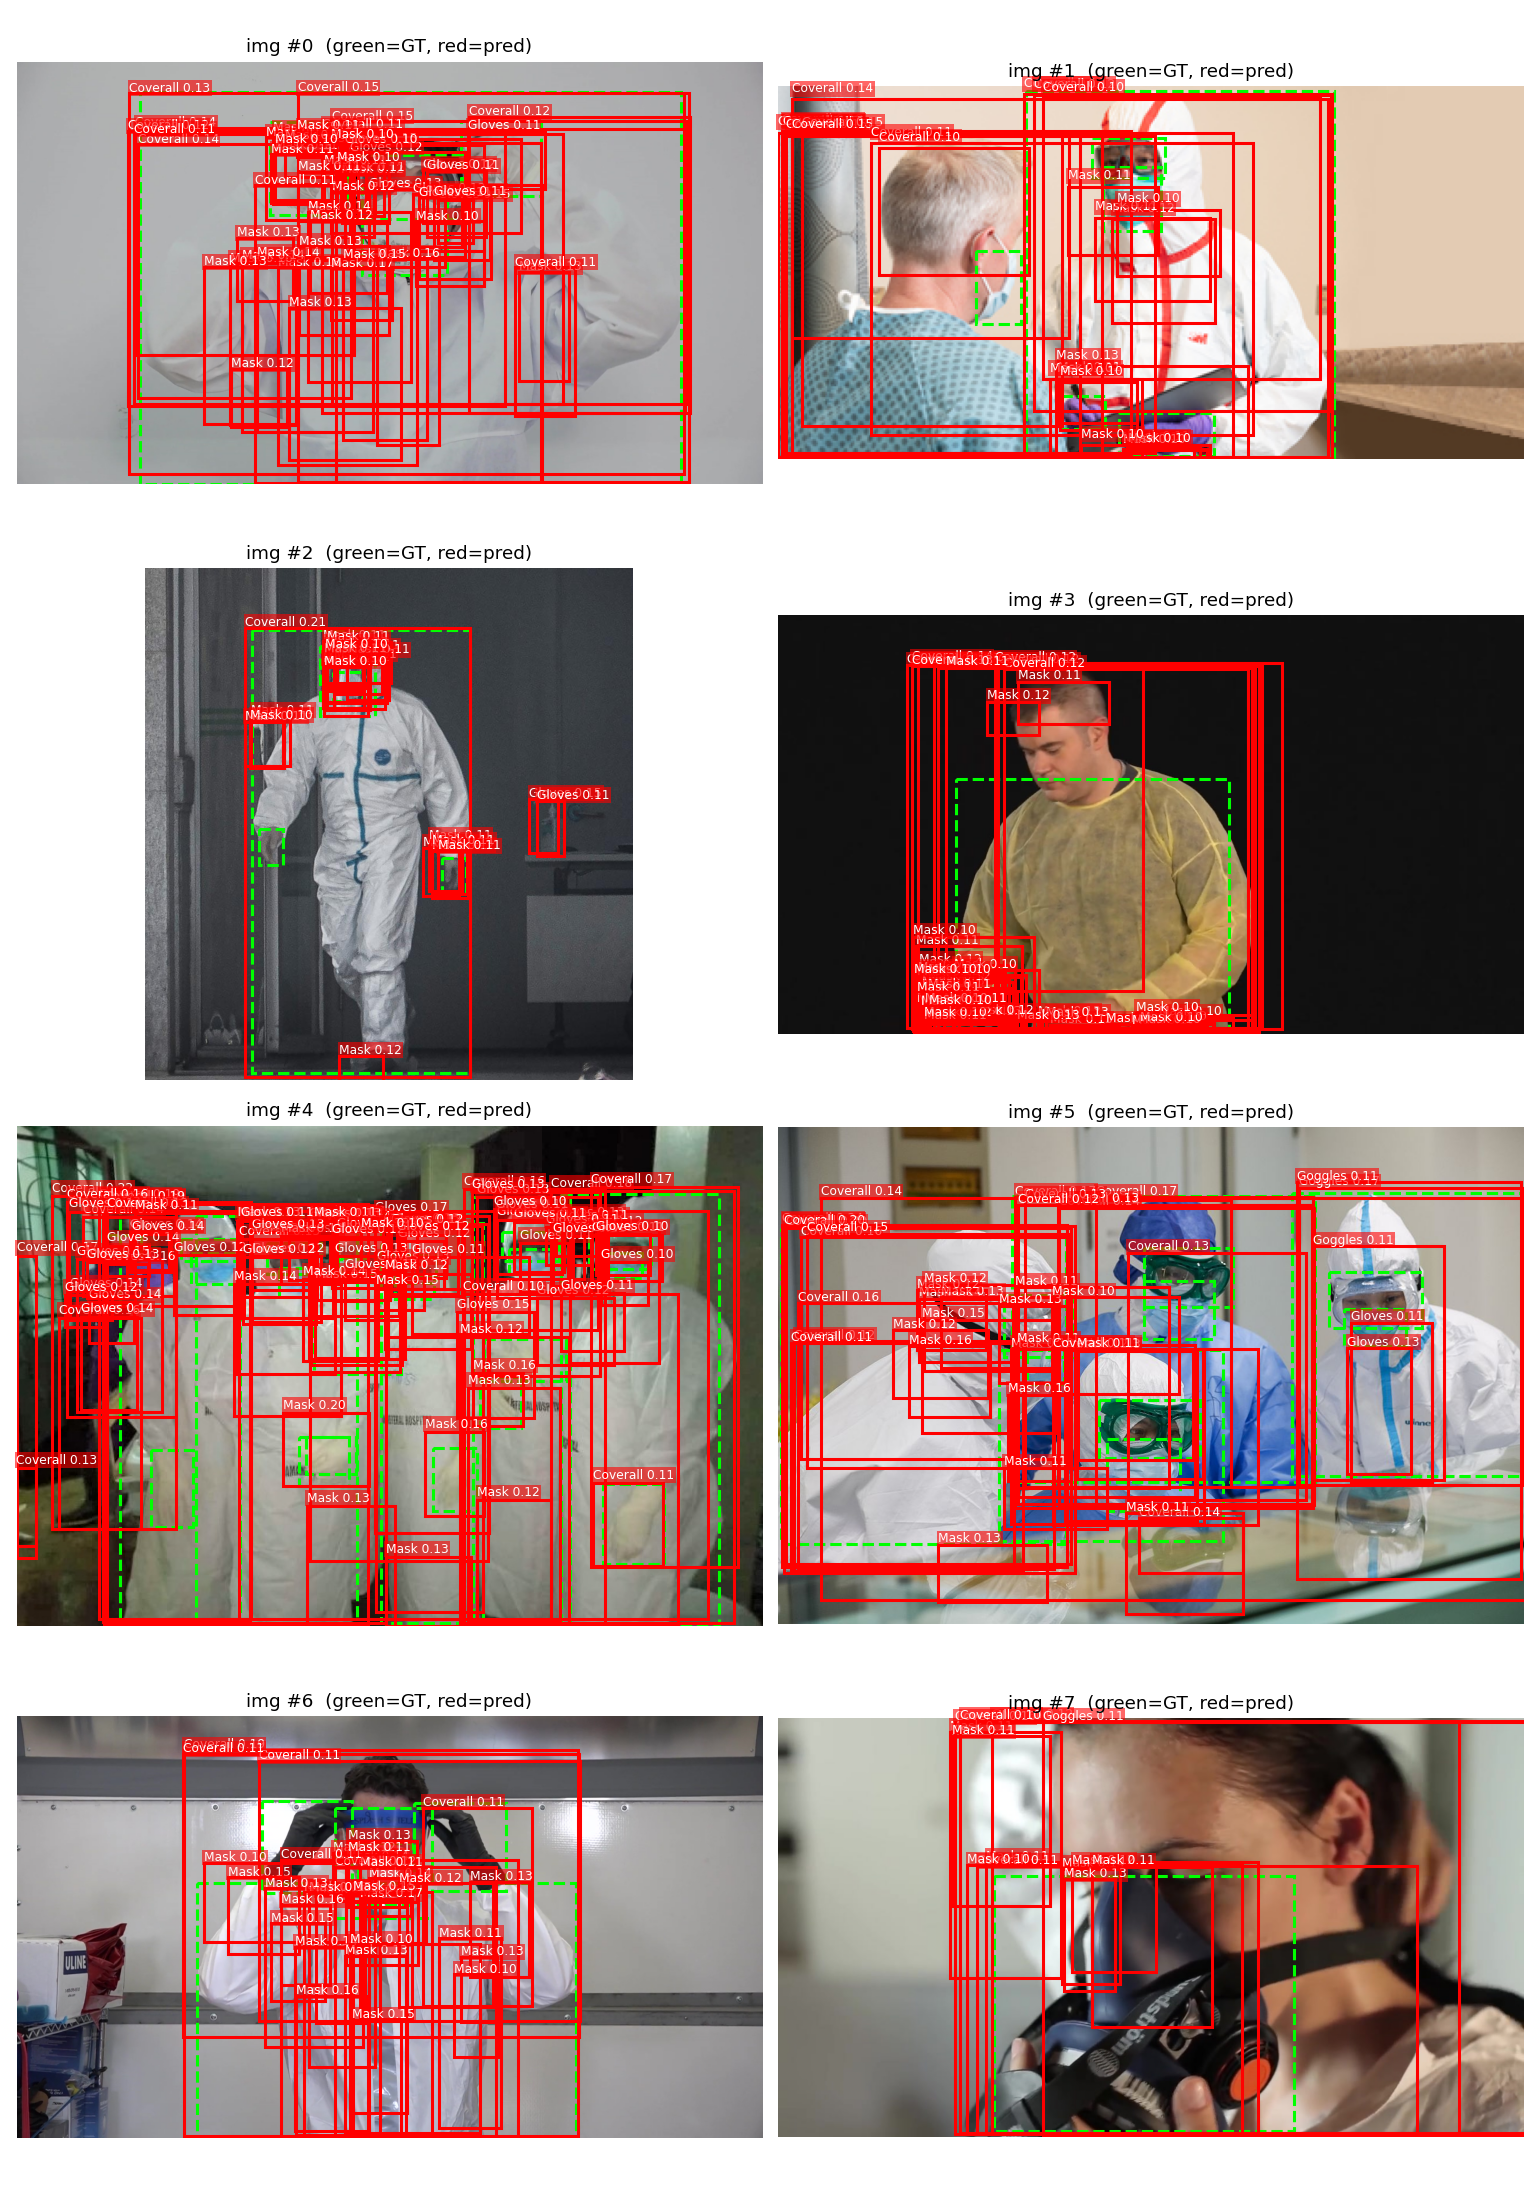

In [23]:
Image('../outputs/figures/predictions.png')

## 8. TensorBoard (loss-кривые по шагам, mAP по эпохам)

In [26]:
%load_ext tensorboard
%tensorboard --logdir ../outputs/runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 87853), started 0:01:44 ago. (Use '!kill 87853' to kill it.)